# Image Classification Using a Pre-Trained Model

## Import Libraries

In [1]:
import torchvision
from matplotlib import lines
from torchvision import models

## Looking at the list of available pre-trained models

In [2]:
# select 5 instances from the list for illustrative purposes
models.list_models()[:5]

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny']

## Selecting Vision Transformer B16

In [3]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

## Print out model architecture details

In [4]:
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

## Transforms

We are going to perform the following transforms:
* Resize the image to 256
* Center crop to 224
* Normalization - use the mean and std. dev. from the ImageNet dataset

In [5]:
from torchvision import transforms
preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], # these are the magic numbers from the ImageNet dataset
            std=[0.229, 0.224, 0.225] # these are the magic numbers from the ImageNet dataset
        )])

## First Image: Dachshund

Dachshund photo
By Raven Underwood - Flickr, CC BY 2.0, https://commons.wikimedia.org/w/index.php?curid=2134661

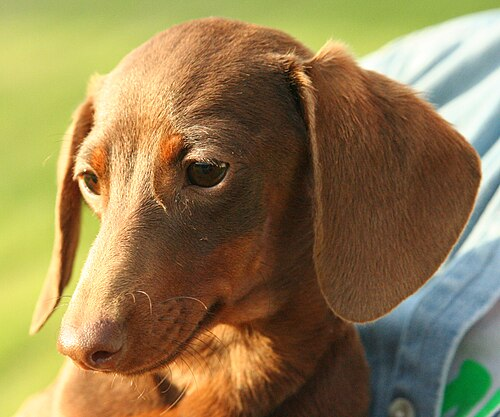

In [6]:
from PIL import Image
img = Image.open("/...data/Dachshund.jpg")
img

In [7]:
# apply transforms to image
img_t = preprocess(img)

In [8]:
# we use unsqueeze to insert a dimension of 1 to the tensor to match expected input shapes
# the model expects a batch of the form (N, C, W, H),
# where N is the batch number
# we unsqueeze (3, 224, 224) into (1, 3, 224, 224)
import torch
batch_t = torch.unsqueeze(img_t, 0)

In [9]:
# set the model to inference mode
vit.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [10]:
# output
out = vit(batch_t)

## This is how the model sees the image

In [11]:
# print the output (tensor)
out

tensor([[ 7.5214e-02, -5.5221e-01, -3.6093e-01,  1.0243e-01, -3.4757e-01,
          3.9535e-02, -4.1651e-01, -7.3966e-02,  4.9208e-01, -1.5641e-01,
         -5.7925e-01, -1.0408e+00, -3.2615e-02, -3.0699e-01, -4.4583e-01,
          1.2770e-01,  1.3750e-01,  6.8356e-02,  4.4722e-01, -2.6747e-01,
          4.4050e-01, -1.8224e-01,  7.4059e-02,  2.0915e-01, -1.5120e-01,
         -3.1396e-02, -5.3280e-01, -1.4846e-01, -2.9007e-01,  5.0600e-02,
         -8.6007e-02, -1.9267e-01,  1.0383e-01, -1.1422e-01,  1.8413e-01,
         -4.5175e-01, -8.0165e-02, -3.2263e-01, -2.8237e-01, -5.5343e-01,
          4.2260e-01, -3.2785e-01,  1.1848e-01, -3.3795e-01, -3.0602e-02,
          6.8917e-02, -4.7202e-02, -4.8407e-02,  2.2175e-01, -5.3642e-02,
         -2.6847e-02, -4.3658e-01,  1.3827e-01, -1.5251e-01,  2.8668e-01,
          9.0281e-02, -6.2550e-02,  4.3881e-01, -6.8028e-03,  4.1086e-01,
         -3.0743e-01, -4.7312e-01, -4.5396e-01, -5.4450e-01, -4.0341e-02,
         -8.1896e-02, -1.9754e-01,  2.

This model has about 88.6 million parameters!

## Import ImageNet dataset class labels

In [12]:
with open('/Users/rick/Downloads/imagenet_classes.txt') as f:
    labels = [line.strip() for line in f.readlines()]

## Determine the index of the max score in the output tensor

In [13]:
_, index = torch.max(out, 1)

## Using the index to access the label

In [14]:
# softmax gives us the probability distribution, so the output is in the [0,1] range
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
labels[index.item()], percentage[index.item()].item()

('Doberman, Doberman pinscher', 79.99667358398438)

Our Dachshund was classified as a Doberman. This is expected as the model did not see Dachshund photos during training. This can be confirmed by looking at the class labels list we already imported 2 steps above. The closest thing the model labels it as is a Doberman.

## What are the top 5 labels?

In [15]:
_, indices = torch.sort(out, descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('Doberman, Doberman pinscher', 79.99667358398438),
 ('Weimaraner', 5.2416863441467285),
 ('vizsla, Hungarian pointer', 1.5058038234710693),
 ('Rhodesian ridgeback', 0.3674171268939972),
 ('miniature pinscher', 0.3521707057952881)]

## Let's try now with images of subjects the model has seen during training...

## Arctic Fox

Photo by Jonathen Pie https://unsplash.com/@r3dmax - https://unsplash.com/photos/NBvcQRdRSeQ, CC0, https://commons.wikimedia.org/w/index.php?curid=67215351

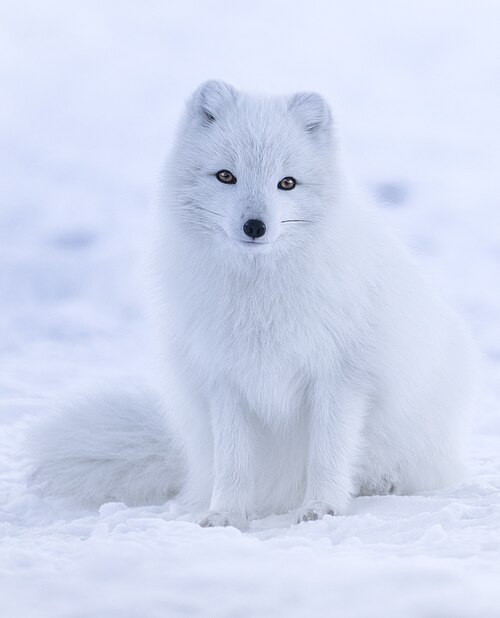

In [16]:
arc_fox = Image.open("/...data/arctic_fox.jpg")
arc_fox

In [17]:
arc_fox_t = preprocess(arc_fox)

In [18]:
batch_arc_fox_t = torch.unsqueeze(arc_fox_t, 0)

In [19]:
out = vit(batch_arc_fox_t)

In [20]:
_, index = torch.max(out, 1)

## This time the model got it right

In [21]:
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
labels[index.item()], percentage[index.item()].item()

('Arctic fox, white fox, Alopex lagopus', 90.57447814941406)

In [22]:
_, indices = torch.sort(out, descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('Arctic fox, white fox, Alopex lagopus', 90.57447814941406),
 ('white wolf, Arctic wolf, Canis lupus tundrarum', 0.15857446193695068),
 ('red fox, Vulpes vulpes', 0.07033968716859818),
 ('grey fox, gray fox, Urocyon cinereoargenteus', 0.04568551853299141),
 ('kit fox, Vulpes macrotis', 0.04127250239253044)]

## Let's try with a red fox

By Joanne Redwood - This file was derived from: Vulpes vulpes ssp fulvus 26568101.jpg, CC0, https://commons.wikimedia.org/w/index.php?curid=106804964

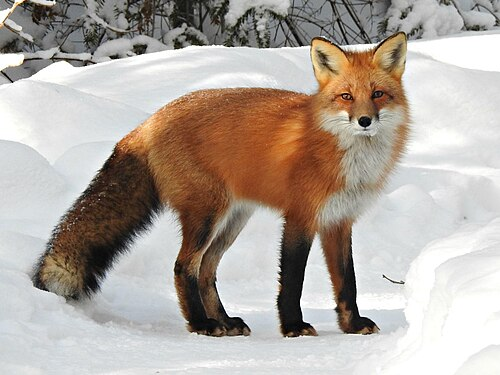

In [23]:
fox = Image.open("/...data/fox.jpg")
fox

In [24]:
fox_t = preprocess(fox)

In [25]:
batch_fox_t = torch.unsqueeze(fox_t, 0)

In [26]:
out = vit(batch_fox_t)

In [27]:
_, index = torch.max(out, 1)

## The model got it right again

In [28]:
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
labels[index.item()], percentage[index.item()].item()

('red fox, Vulpes vulpes', 84.16948699951172)

In [29]:
_, indices = torch.sort(out, descending=True)
[(labels[idx], percentage[idx].item()) for idx in indices[0][:5]]

[('red fox, Vulpes vulpes', 84.16948699951172),
 ('grey fox, gray fox, Urocyon cinereoargenteus', 3.659160852432251),
 ('kit fox, Vulpes macrotis', 0.6696045994758606),
 ('dhole, Cuon alpinus', 0.262322336435318),
 ('Arctic fox, white fox, Alopex lagopus', 0.21182264387607574)]

## Conclusion

We have seen that using pre-trained models along with their pre-optimized weights can be a good alternative to training computer vision models from scratch. These pre-trained models are easy to access and use and can be found in repositories like Torchvision and HuggingFace.